# Advanced Results Processing

This notebook demonstrates advanced techniques for extracting and processing ospgrillage results using [xarray](http://xarray.pydata.org/en/stable/). It builds on the [Super-T Tutorial](super_t_tutorial.ipynb).

## Setup

We first recreate the Super-T bridge model from the tutorial. See that notebook for detailed explanations.

In [1]:
import ospgrillage as og
import numpy as np

# Units
kilo, milli, N, m = 1e3, 1e-3, 1, 1
mm = milli * m
m2, m3, m4 = m**2, m**3, m**4
kN = kilo * N
MPa = N / mm**2
GPa = kilo * MPa

In [2]:
concrete = og.create_material(material="concrete", code="AS5100-2017", grade="65MPa")

longitudinal_section = og.create_section(A=1.025*m2, J=0.1878*m3, Iz=0.3694*m4, Iy=0.3634*m4, Az=0.4979*m2, Ay=0.309*m2)
edge_longitudinal_section = og.create_section(A=0.934*m2, J=0.1857*m3, Iz=0.3478*m4, Iy=0.213602*m4, Az=0.444795*m2, Ay=0.258704*m2)
transverse_section = og.create_section(A=0.504*m2, J=5.22303e-3*m3, Iy=0.32928*m4, Iz=1.3608e-3*m4, Ay=0.42*m2, Az=0.42*m2, unit_width=True)
end_transverse_section = og.create_section(A=0.504/2*m2, J=2.5e-3*m3, Iy=2.73e-2*m4, Iz=6.8e-4*m4, Ay=0.21*m2, Az=0.21*m2, unit_width=True)

longitudinal_beam = og.create_member(section=longitudinal_section, material=concrete)
edge_longitudinal_beam = og.create_member(section=edge_longitudinal_section, material=concrete)
transverse_slab = og.create_member(section=transverse_section, material=concrete)
end_transverse_slab = og.create_member(section=end_transverse_section, material=concrete)

In [3]:
L = 33.5 * m
w = 11.565 * m

model = og.create_grillage(
    bridge_name="Super-T 33_5m", long_dim=L, width=w, skew=0,
    num_long_grid=7, num_trans_grid=11, edge_beam_dist=1.05 * m,
)
model.set_member(longitudinal_beam, member="interior_main_beam")
model.set_member(longitudinal_beam, member="exterior_main_beam_1")
model.set_member(longitudinal_beam, member="exterior_main_beam_2")
model.set_member(edge_longitudinal_beam, member="edge_beam")
model.set_member(transverse_slab, member="transverse_slab")
model.set_member(end_transverse_slab, member="start_edge")
model.set_member(end_transverse_slab, member="end_edge")
model.create_osp_model(pyfile=False)

In [4]:
# Dead loads
beam_mag = 22.4 * kN / m
DL_self_weight = og.create_load_case(name="Super T self weight")
for z_pos in model.Mesh_obj.noz[1:-1]:
    p1 = og.create_load_vertex(x=0, z=z_pos, p=beam_mag)
    p2 = og.create_load_vertex(x=L, z=z_pos, p=beam_mag)
    DL_self_weight.add_load(og.create_load(loadtype="line", point1=p1, point2=p2, name="SW"))
model.add_load_case(DL_self_weight)

# Overlay slab
overlay = og.create_load(loadtype="patch", name="overlay",
    point1=og.create_load_vertex(x=0, z=0, p=4.32*kN/m2),
    point2=og.create_load_vertex(x=L, z=0, p=4.32*kN/m2),
    point3=og.create_load_vertex(x=L, z=w, p=4.32*kN/m2),
    point4=og.create_load_vertex(x=0, z=w, p=4.32*kN/m2))
DL_overlay = og.create_load_case(name="Overlay self weight")
DL_overlay.add_load(overlay)
model.add_load_case(DL_overlay)

# SIDL
asphalt = og.create_load(loadtype="patch", name="asphalt",
    point1=og.create_load_vertex(x=0, z=0, p=1.43*kN/m2),
    point2=og.create_load_vertex(x=L, z=0, p=1.43*kN/m2),
    point3=og.create_load_vertex(x=L, z=w, p=1.43*kN/m2),
    point4=og.create_load_vertex(x=0, z=w, p=1.43*kN/m2))
left_barrier = og.create_load(loadtype="line", name="left barrier",
    point1=og.create_load_vertex(x=0, z=0, p=6.54*kN/m),
    point2=og.create_load_vertex(x=L, z=0, p=6.54*kN/m))
right_barrier = og.create_load(loadtype="line", name="right barrier",
    point1=og.create_load_vertex(x=0, z=w, p=6.54*kN/m),
    point2=og.create_load_vertex(x=L, z=w, p=6.54*kN/m))
SIDL = og.create_load_case(name="SIDL")
SIDL.add_load(asphalt)
SIDL.add_load(left_barrier)
SIDL.add_load(right_barrier)
model.add_load_case(SIDL)

# M1600 traffic
gap = 6.25 * m
z_coord = [w/2, w/2 - 3.2*m, w/2 + 3.2*m]
alf = [1.0, 0.8, 0.4]
dla = 1.3
udl_width = 3.2 * m
udl_mag = 6*kN/m / udl_width

m1600_lc_list = [og.create_load_case(name=f"M1600 L{i+1}") for i in range(3)]
M1600_moving_loads = []
for i in range(3):
    vehicle = og.create_load_model(model_type="M1600", gap=gap).create()
    vehicle.set_global_coord(og.Point(0, 0, z_coord[i]))
    m1600_lc_list[i].add_load(vehicle, load_factor=alf[i])
    M1600_moving_loads.append(vehicle)
    udl = og.create_load(loadtype="patch", name="UDL",
        point1=og.create_load_vertex(x=-L, z=z_coord[i]-udl_width/2, p=udl_mag),
        point2=og.create_load_vertex(x=2*L, z=z_coord[i]-udl_width/2, p=udl_mag),
        point3=og.create_load_vertex(x=2*L, z=z_coord[i]+udl_width/2, p=udl_mag),
        point4=og.create_load_vertex(x=-L, z=z_coord[i]+udl_width/2, p=udl_mag))
    m1600_lc_list[i].add_load(udl, load_factor=alf[i])
    model.add_load_case(m1600_lc_list[i], load_factor=dla)

# Moving loads
path = og.create_moving_path(
    start_point=og.create_point(x=-25, y=0, z=0),
    end_point=og.Point(L, 0, 0))
for i in range(3):
    ml = og.create_moving_load(name=f"Moving M1600 L{i+1}")
    ml.set_path(path)
    ml.add_load(M1600_moving_loads[i])
    model.add_load_case(ml)

In [5]:
model.analyze()

## Understanding the Results Dataset

The `get_results()` method returns an xarray `Dataset` containing multiple `DataArray` objects. Each DataArray is indexed along named dimensions.

In [6]:
results = model.get_results()
results

<xarray.Dataset> Size: 14MB
Dimensions:        (Loadcase: 156, Node: 77, Component: 30, Element: 136,
                    Nodes: 2)
Coordinates:
  * Loadcase       (Loadcase) <U53 33kB 'Super T self weight' ... 'Moving M16...
  * Node           (Node) int64 616B 1 2 3 4 5 6 7 8 ... 70 71 72 73 74 75 76 77
  * Component      (Component) <U9 1kB 'Mx_i' 'Mx_j' 'My_i' ... 'x' 'y' 'z'
  * Element        (Element) int64 1kB 1 2 3 4 5 6 7 ... 131 132 133 134 135 136
  * Nodes          (Nodes) <U1 8B 'i' 'j'
Data variables:
    displacements  (Loadcase, Node, Component) object 3MB nan nan ... 0.0
    velocity       (Loadcase, Node, Component) object 3MB nan nan ... nan nan
    acceleration   (Loadcase, Node, Component) object 3MB nan nan ... nan nan
    forces         (Loadcase, Element, Component) object 5MB -49532.626215050...
    ele_nodes      (Element, Nodes) object 2kB 1 2 2 3 3 4 ... 75 12 76 13 77 14

The Dataset contains several DataArrays, each indexed along named dimensions:

- **`displacements`** — `(Loadcase, Node, Component)` with translations (`x, y, z`), rotations (`theta_x, …`), velocities (`dx, dy, dz`), and accelerations (`ddx, …`)
- **`forces`** — `(Loadcase, Element, Component)` with i-end and j-end forces (`Vx_i, Vy_i, …, Mz_j`)
- **`ele_nodes`** — maps each Element tag to its `i` and `j` node tags

The `Loadcase` dimension includes both static and moving load case names. Each moving load increment is stored as a separate load case named `"<name> at global position [x,y,z]"`, so even a modest model can have hundreds of load cases. Rather than printing them all, it's useful to summarise:

In [7]:
# Summarise the load cases in the results
loadcases = list(results.coords["Loadcase"].values)
print(f"Total load cases: {len(loadcases)}")

# Separate static from moving (moving load names contain "at global position")
static_lc = [lc for lc in loadcases if "at global position" not in lc]
moving_lc = [lc for lc in loadcases if "at global position" in lc]

print(f"\nStatic load cases ({len(static_lc)}):")
for lc in static_lc:
    print(f"  - {lc}")

print(f"\nMoving load increments: {len(moving_lc)}")
if moving_lc:
    print(f"  First: {moving_lc[0]}")
    print(f"  Last:  {moving_lc[-1]}")

# Show the available component names (cast to plain str for tidy output)
disp_comps = [str(c) for c in results.displacements.coords["Component"].values]
force_comps = [str(c) for c in results.forces.coords["Component"].values]

# Displacement: translation + rotation + velocity + acceleration
translations = [c for c in disp_comps if c in ("x", "y", "z")]
rotations    = [c for c in disp_comps if c.startswith("theta")]
print(f"\nDisplacement components ({len(disp_comps)} total):")
print(f"  Translations: {translations}")
print(f"  Rotations:    {rotations}")

# Forces: i-end and j-end
force_i = [c for c in force_comps if c.endswith("_i")]
force_j = [c for c in force_comps if c.endswith("_j")]
print(f"\nForce components ({len(force_comps)} total):")
print(f"  i-end: {force_i}")
print(f"  j-end: {force_j}")

Total load cases: 156

Static load cases (6):
  - Super T self weight
  - Overlay self weight
  - SIDL
  - M1600 L1
  - M1600 L2
  - M1600 L3

Moving load increments: 150
  First: Moving M1600 L1 at global position [-25.00,0.00,0.00]
  Last:  Moving M1600 L3 at global position [33.50,0.00,0.00]

Displacement components (30 total):
  Translations: ['x', 'y', 'z']
  Rotations:    ['theta_x', 'theta_y', 'theta_z']

Force components (30 total):
  i-end: ['Mx_i', 'My_i', 'Mz_i', 'Vx_i', 'Vy_i', 'Vz_i']
  j-end: ['Mx_j', 'My_j', 'Mz_j', 'Vx_j', 'Vy_j', 'Vz_j']


In [8]:
# Access a specific DataArray
displacements = results.displacements
forces = results.forces
print(f"Displacements shape: {displacements.shape}")
print(f"Forces shape: {forces.shape}")

Displacements shape: (156, 77, 30)
Forces shape: (156, 136, 30)


## Selecting Results with `.sel()`

xarray's `.sel()` method is the primary way to extract specific results. You can select along any dimension.

In [9]:
# Select vertical displacement for a specific load case
dy_sw = results.displacements.sel(Loadcase="Super T self weight", Component="y")
print(f"Self-weight deflections (first 5 nodes): {dy_sw.values[:5]}")

Self-weight deflections (first 5 nodes): [0.0003544279832746978 0.0 0.0 0.0 0.0]


In [10]:
# Select bending moment for specific elements
member_name = "exterior_main_beam_1"
ext_beam_elements = model.get_element(member=member_name, options="elements")
ext_beam_nodes = model.get_element(member=member_name, options="nodes")

mz = results.forces.sel(Loadcase="M1600 L1", Component="Mz_i", Element=ext_beam_elements)
print(f"M1600 L1 bending moments on Beam 1 (kNm):\n{mz.values / 1000}")

M1600 L1 bending moments on Beam 1 (kNm):
[2.5831676077577286 314.38658863596106 671.1786019299823
 1009.9015807302759 1213.742805394702 1247.0461404027499
 1117.6406533931895 852.9678917010536 511.00958493862504
 203.61613093435963]


In [11]:
# Select multiple load cases at once
multi_lc = results.forces.sel(
    Loadcase=["M1600 L1", "M1600 L2", "M1600 L3"],
    Component="Mz_i",
    Element=ext_beam_elements,
)
print(f"Shape: {multi_lc.shape}  (3 load cases x {len(ext_beam_elements)} elements)")

Shape: (3, 10)  (3 load cases x 10 elements)


## Filtering by Load Case Type

Use the `load_case` keyword to retrieve only specific load cases. This is useful when you want to work with static or moving results separately.

In [12]:
# Static load cases only
static_results = model.get_results(
    load_case=["Super T self weight", "SIDL", "Overlay self weight",
               "M1600 L1", "M1600 L2", "M1600 L3"]
)
static_results

<xarray.Dataset> Size: 546kB
Dimensions:        (Loadcase: 6, Node: 77, Component: 30, Element: 136, Nodes: 2)
Coordinates:
  * Loadcase       (Loadcase) <U53 1kB 'Super T self weight' ... 'M1600 L3'
  * Node           (Node) int64 616B 1 2 3 4 5 6 7 8 ... 70 71 72 73 74 75 76 77
  * Component      (Component) <U9 1kB 'Mx_i' 'Mx_j' 'My_i' ... 'x' 'y' 'z'
  * Element        (Element) int64 1kB 1 2 3 4 5 6 7 ... 131 132 133 134 135 136
  * Nodes          (Nodes) <U1 8B 'i' 'j'
Data variables:
    displacements  (Loadcase, Node, Component) object 111kB nan nan ... 0.0
    velocity       (Loadcase, Node, Component) object 111kB nan nan ... nan nan
    acceleration   (Loadcase, Node, Component) object 111kB nan nan ... nan nan
    forces         (Loadcase, Element, Component) object 196kB -49532.6262150...
    ele_nodes      (Loadcase, Element, Nodes) object 13kB 1 2 2 3 ... 13 77 14

In [13]:
# Moving load results for Lane 2
moving_results = model.get_results(load_case="Moving M1600 L2")
print(f"Moving load has {len(moving_results.coords['Loadcase'])} incremental positions")
moving_results

Moving load has 50 incremental positions


<xarray.Dataset> Size: 5MB
Dimensions:        (Loadcase: 50, Node: 77, Component: 30, Element: 136,
                    Nodes: 2)
Coordinates:
  * Loadcase       (Loadcase) <U53 11kB 'Moving M1600 L2 at global position [...
  * Node           (Node) int64 616B 1 2 3 4 5 6 7 8 ... 70 71 72 73 74 75 76 77
  * Component      (Component) <U9 1kB 'Mx_i' 'Mx_j' 'My_i' ... 'x' 'y' 'z'
  * Element        (Element) int64 1kB 1 2 3 4 5 6 7 ... 131 132 133 134 135 136
  * Nodes          (Nodes) <U1 8B 'i' 'j'
Data variables:
    displacements  (Loadcase, Node, Component) object 924kB nan nan ... 0.0
    velocity       (Loadcase, Node, Component) object 924kB nan nan ... nan nan
    acceleration   (Loadcase, Node, Component) object 924kB nan nan ... nan nan
    forces         (Loadcase, Element, Component) object 2MB -2.8109499114186...
    ele_nodes      (Loadcase, Element, Nodes) object 109kB 1 2 2 3 ... 13 77 14

## Load Combinations

Pass a dictionary of `{load_case_name: factor}` to compute factored combinations on the fly.

In [14]:
combination = {
    "Super T self weight": 1.0,
    "M1600 L1": 1.0,
    "M1600 L2": 1.0,
    "M1600 L3": 1.0,
    "SIDL": 1.3,
    "Overlay self weight": 1.0,
}
comb_results = model.get_results(combinations=combination)
comb_results

<xarray.Dataset> Size: 93kB
Dimensions:        (Node: 77, Component: 30, Element: 136, Nodes: 2)
Coordinates:
  * Node           (Node) int64 616B 1 2 3 4 5 6 7 8 ... 70 71 72 73 74 75 76 77
  * Component      (Component) <U9 1kB 'Mx_i' 'Mx_j' 'My_i' ... 'x' 'y' 'z'
  * Element        (Element) int64 1kB 1 2 3 4 5 6 7 ... 131 132 133 134 135 136
  * Nodes          (Nodes) <U1 8B 'i' 'j'
Data variables:
    displacements  (Node, Component) object 18kB nan nan ... 0.0
    velocity       (Node, Component) object 18kB nan nan nan nan ... nan nan nan
    acceleration   (Node, Component) object 18kB nan nan nan nan ... nan nan nan
    forces         (Element, Component) object 33kB -190594.99977260377 ... nan
    ele_nodes      (Element, Nodes) object 2kB 6.3 12.6 12.6 ... 81.9 485.1 88.2

In [15]:
# Extract maximum combined bending moment
comb_mz = comb_results.forces.sel(Component="Mz_i", Element=ext_beam_elements)
print(f"Max combined BM on Beam 1 = {max(comb_mz.values / 1000):.2f} kN m")

Max combined BM on Beam 1 = 8056.09 kN m


## Envelopes

The `create_envelope()` function finds the maximum (or minimum) response across all load cases for each element. This is essential for design — it tells you the worst-case response regardless of which load case caused it.

In [16]:
# Envelope of static load cases
envelope = og.create_envelope(ds=static_results, load_effect="Mz_i", array="forces")
bending_env = envelope.get()
bending_env

<xarray.DataArray 'forces' (Element: 136, Component: 30)> Size: 33kB
array([[-5766.971287611712, -1301.6871548825475, -0.0, ..., nan, nan,
        nan],
       [19379.122833006462, 20228.821098686087, -0.0, ..., nan, nan, nan],
       [25026.028246443362, 28974.427908192403, -0.0, ..., nan, nan, nan],
       ...,
       [49399.21342455591, 40113.337141747936, 0.0, ..., nan, nan, nan],
       [57392.499131043674, -11412.184752349436, 0.0, ..., nan, nan, nan],
       [49532.549375156814, -5732.405980895863, 0.0, ..., nan, nan, nan]],
      shape=(136, 30), dtype=object)
Coordinates:
  * Element    (Element) int64 1kB 1 2 3 4 5 6 7 ... 130 131 132 133 134 135 136
  * Component  (Component) <U9 1kB 'Mx_i' 'Mx_j' 'My_i' 'My_j' ... 'x' 'y' 'z'

In [17]:
# Envelope of moving load positions
moving_envelope = og.create_envelope(ds=moving_results, load_effect="Mz_i", array="forces")
moving_env = moving_envelope.get()
moving_env.sel(Element=ext_beam_elements, Component="Mz_i")

<xarray.DataArray 'forces' (Element: 10)> Size: 80B
array([2.898838219938375e-11, 1110897.0641365775, 1320696.3477219772,
       1562899.103927729, 1754332.3989951187, 1793432.9329442605,
       1776146.041865552, 1616824.7536388212, 1386801.6559747346,
       1192240.6062729044], dtype=object)
Coordinates:
  * Element    (Element) int64 80B 20 33 46 59 72 85 98 111 124 131
    Component  <U9 36B 'Mz_i'

### Query Mode — Which Load Case Governs?

Set `query_mode=True` to find out which load case produced the maximum at each element. The result is a DataArray whose values are load case **name strings** — one per element — telling you which position governs.

In [18]:
query_envelope = og.create_envelope(
    ds=moving_results, load_effect="Mz_i", array="forces", query_mode=True
)
query_env = query_envelope.get()

# Which moving load position gives max BM on each element of Beam 1?
governing = query_env.sel(Element=ext_beam_elements, Component="Mz_i")
print("Governing load case per element:")
for elem, lc_name in zip(governing.Element.values, governing.values):
    print(f"  Element {elem}: {lc_name}")

Governing load case per element:
  Element 20: Moving M1600 L2 at global position [33.50,0.00,0.00]
  Element 33: Moving M1600 L2 at global position [2.46,0.00,0.00]
  Element 46: Moving M1600 L2 at global position [4.85,0.00,0.00]
  Element 59: Moving M1600 L2 at global position [3.65,0.00,0.00]
  Element 72: Moving M1600 L2 at global position [6.04,0.00,0.00]
  Element 85: Moving M1600 L2 at global position [4.85,0.00,0.00]
  Element 98: Moving M1600 L2 at global position [7.23,0.00,0.00]
  Element 111: Moving M1600 L2 at global position [8.43,0.00,0.00]
  Element 124: Moving M1600 L2 at global position [9.62,0.00,0.00]
  Element 131: Moving M1600 L2 at global position [10.82,0.00,0.00]


## Custom Post-Processing

Extract numpy arrays for custom calculations.

In [19]:
# Support nodes sit on the bridge edges (edge_node_recorder maps node tag -> edge group)
support_nodes = list(model.Mesh_obj.edge_node_recorder.keys())
print(f"Support node tags ({len(support_nodes)}): {support_nodes}")

# Vertical displacement at supports under self-weight (should be near zero)
dy_supports = results.displacements.sel(
    Loadcase="Super T self weight", Component="y", Node=support_nodes
)
print(f"Support deflections: {dy_supports.values}")

Support node tags (14): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
Support deflections: [0.0003544279832746978 0.0 0.0 0.0 0.0 0.0 0.0003544135287553898
 0.00035442798327482223 0.0 0.0 0.0 0.0 0.0 0.000354413528755353]


In [20]:
# Compare maximum bending across all beams
for member in ["exterior_main_beam_1", "interior_main_beam", "exterior_main_beam_2"]:
    elements = model.get_element(member=member, options="elements")
    mz = results.forces.sel(Loadcase="M1600 L1", Component="Mz_i", Element=elements)
    print(f"{member}: max Mz = {max(mz.values) / 1000:.1f} kN m")

exterior_main_beam_1: max Mz = 1247.0 kN m
interior_main_beam: max Mz = 1676.3 kN m
exterior_main_beam_2: max Mz = 1247.0 kN m


## Filtering Member Groups in Plots

The convenience plotting functions (`plot_bmd`, `plot_sfd`, `plot_def`) accept a `member` parameter that controls which member groups are plotted. You can pass:

- A **string** — a single member name (e.g. `"interior_main_beam"`)
- An `og.Members` **bitflag** — one or more groups combined with `|`
- `None` (default) — all members for plotly, longitudinal only for matplotlib

The `og.Members` enum provides individual flags for each member type and pre-defined composites for common selections:

In [21]:
# Available flags
print("Individual flags:")
for flag in og.Members:
    print(f"  og.Members.{flag.name}")

print("\nComposites:")
print(f"  og.Members.LONGITUDINAL = {og.Members.LONGITUDINAL}")
print(f"  og.Members.TRANSVERSE   = {og.Members.TRANSVERSE}")
print(f"  og.Members.ALL          = {og.Members.ALL}")

Individual flags:
  og.Members.EDGE_BEAM
  og.Members.EXTERIOR_MAIN_BEAM_1
  og.Members.INTERIOR_MAIN_BEAM
  og.Members.EXTERIOR_MAIN_BEAM_2
  og.Members.START_EDGE
  og.Members.END_EDGE
  og.Members.TRANSVERSE_SLAB

Composites:
  og.Members.LONGITUDINAL = Members.LONGITUDINAL
  og.Members.TRANSVERSE   = Members.TRANSVERSE
  og.Members.ALL          = Members.ALL


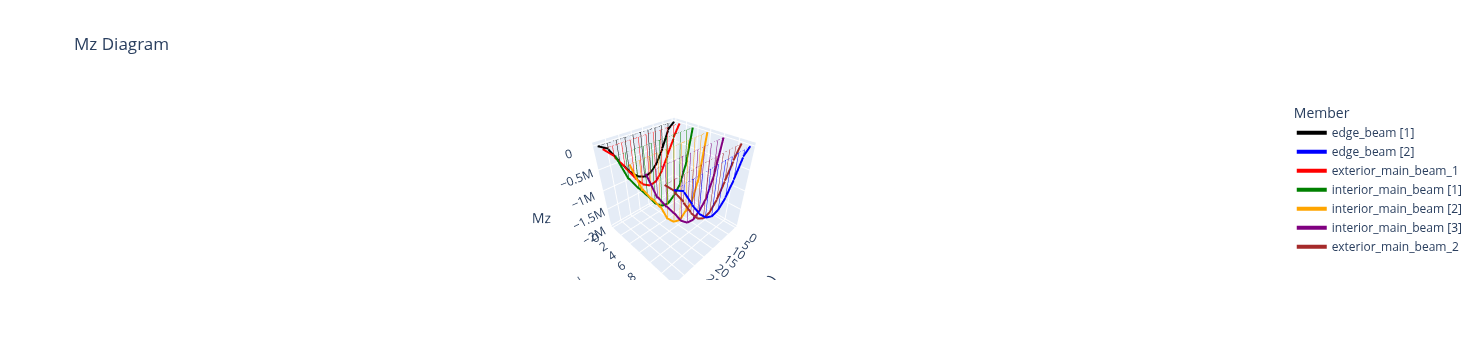

In [22]:
# Plot BMD for longitudinal members only
og.plot_bmd(model, static_results, member=og.Members.LONGITUDINAL,
            loadcase="M1600 L1", backend="plotly", figsize=(14, 8));

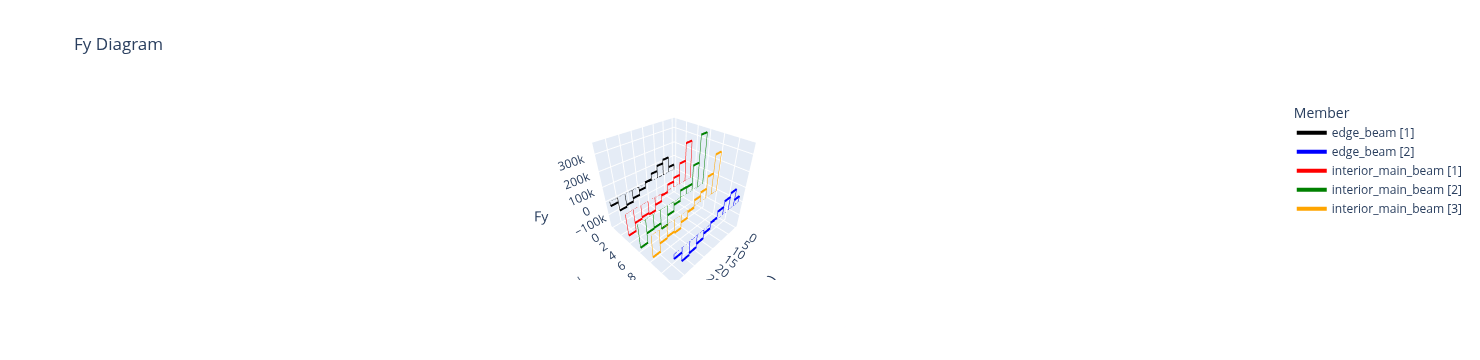

In [23]:
# Combine individual flags to plot just edge beam and interior main beam
og.plot_sfd(model, static_results,
            member=og.Members.EDGE_BEAM | og.Members.INTERIOR_MAIN_BEAM,
            loadcase="M1600 L1", backend="plotly", figsize=(14, 8));

In [24]:
# Plot deflection for transverse members only
og.plot_def(model, static_results,
            member=og.Members.TRANSVERSE,
            loadcase="M1600 L1", backend="plotly", figsize=(14, 8));

TypeError: only 0-dimensional arrays can be converted to Python scalars

## Summary

Key techniques covered:

| Technique | Method |
|---|---|
| Select specific results | `results.forces.sel(Loadcase=..., Component=..., Element=...)` |
| Filter load cases | `model.get_results(load_case=[...])` |
| Load combinations | `model.get_results(combinations={...})` |
| Envelopes | `og.create_envelope(ds=..., load_effect=..., array=...)` |
| Query governing case | `og.create_envelope(..., query_mode=True)` |
| Extract numpy arrays | `.values` on any DataArray |
| Filter member groups | `og.plot_bmd(..., member=og.Members.LONGITUDINAL)` |